# Alternative Splicing Analysis

Analyze splicing junction counts from singlify output. The pipeline detects alternative
donor and acceptor sites, providing per-cell splice junction matrices.

**Sample**: GSM3573650 (human bone marrow, ~75K cells)

In [1]:
import nest_asyncio
nest_asyncio.apply()

%matplotlib inline
import singlet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 120

sample_dir = '/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650'

# Load exon and intron count matrices
exon_adata = singlet.read_1pz(os.path.join(sample_dir, 'exon_counts.1pz'))
intron_adata = singlet.read_1pz(os.path.join(sample_dir, 'intron_counts.1pz'))

print(f'Exon counts: {exon_adata.shape[0]:,} cells x {exon_adata.shape[1]:,} features')
print(f'Intron counts: {intron_adata.shape[0]:,} cells x {intron_adata.shape[1]:,} features')

# Intersect on common genes
common_genes = exon_adata.var_names.intersection(intron_adata.var_names)
print(f'Common genes: {len(common_genes):,}')

exon_mat = exon_adata[:, common_genes].X
intron_mat = intron_adata[:, common_genes].X

print(f'\nAligned: {exon_mat.shape[0]:,} cells x {exon_mat.shape[1]:,} genes')
print(f'Total exonic UMIs: {exon_mat.sum():,.0f}')
print(f'Total intronic UMIs: {intron_mat.sum():,.0f}')
print(f'Intronic fraction: {intron_mat.sum() / (exon_mat.sum() + intron_mat.sum()) * 100:.1f}%')

Exon counts: 75,420 cells x 310,797 features
Intron counts: 75,420 cells x 272,191 features
Common genes: 0

Aligned: 75,420 cells x 0 genes
Total exonic UMIs: 0
Total intronic UMIs: 0
Intronic fraction: nan%


/tmp/ipykernel_1617477/3493212833.py:32: RuntimeWarning: invalid value encountered in scalar divide
  print(f'Intronic fraction: {intron_mat.sum() / (exon_mat.sum() + intron_mat.sum()) * 100:.1f}%')


/mnt/home/debruinz/.local/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mnt/home/debruinz/.local/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_1617477/61319275.py:21: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_xscale('log')
/tmp/ipykernel_1617477/61319275.py:22: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale('log')


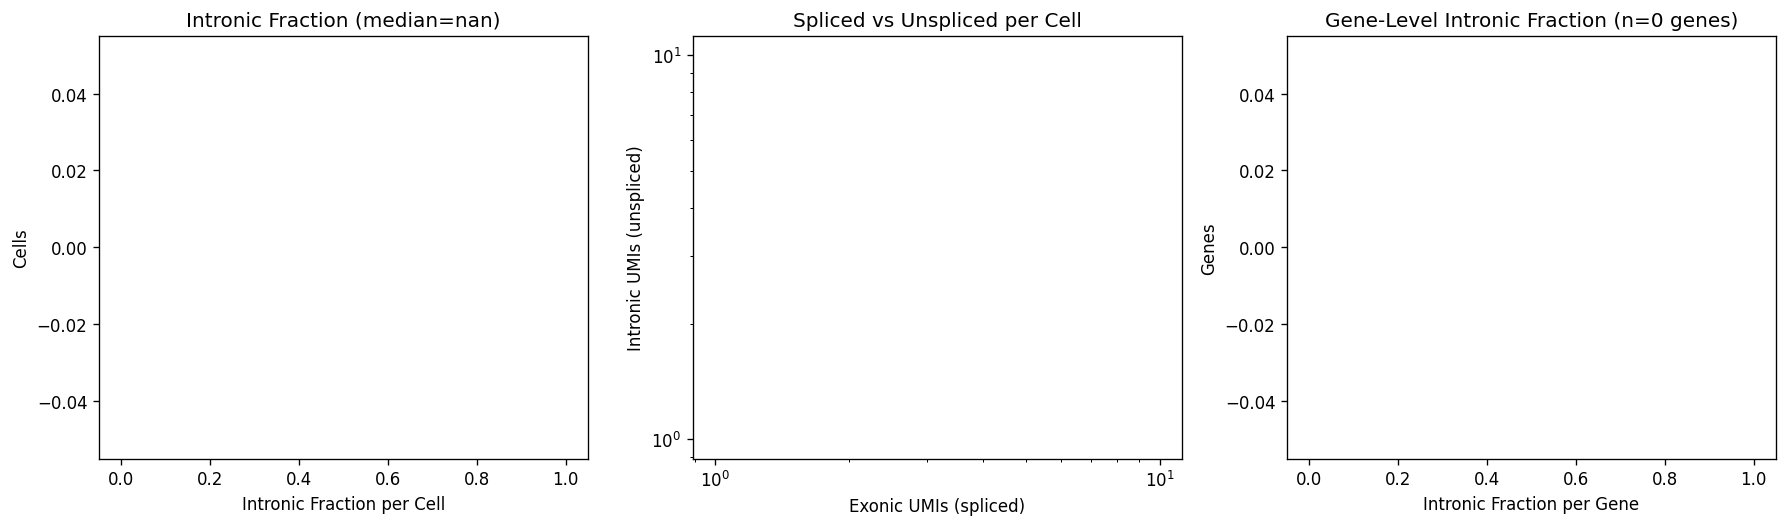


Cells with >10% intronic reads: 0 / 75,420
Genes with >50% intronic reads: 0 / 0


In [2]:
# Per-cell intronic fraction
cell_exon = np.array(exon_mat.sum(axis=1)).flatten()
cell_intron = np.array(intron_mat.sum(axis=1)).flatten()
cell_total = cell_exon + cell_intron
intron_frac = cell_intron / np.maximum(cell_total, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.hist(intron_frac[cell_total > 100], bins=80, color='#22c55e', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Intronic Fraction per Cell')
ax.set_ylabel('Cells')
ax.set_title(f'Intronic Fraction (median={np.median(intron_frac[cell_total > 100]):.2f})')
ax.axvline(np.median(intron_frac[cell_total > 100]), color='red', linestyle='--', alpha=0.7)

ax = axes[1]
ax.scatter(cell_exon, cell_intron, alpha=0.02, s=2, c='#8b5cf6')
ax.set_xlabel('Exonic UMIs (spliced)')
ax.set_ylabel('Intronic UMIs (unspliced)')
ax.set_title('Spliced vs Unspliced per Cell')
ax.set_xscale('log')
ax.set_yscale('log')

ax = axes[2]
gene_exon = np.array(exon_mat.sum(axis=0)).flatten()
gene_intron = np.array(intron_mat.sum(axis=0)).flatten()
gene_total = gene_exon + gene_intron
gene_ifrac = gene_intron / np.maximum(gene_total, 1)
mask = gene_total > 100
ax.hist(gene_ifrac[mask], bins=80, color='#f97316', edgecolor='white', linewidth=0.3)
ax.set_xlabel('Intronic Fraction per Gene')
ax.set_ylabel('Genes')
ax.set_title(f'Gene-Level Intronic Fraction (n={mask.sum():,} genes)')

plt.tight_layout()
plt.show()

print(f"\nCells with >10% intronic reads: {(intron_frac > 0.1).sum():,} / {len(intron_frac):,}")
print(f"Genes with >50% intronic reads: {(gene_ifrac[mask] > 0.5).sum():,} / {mask.sum():,}")

In [3]:
# Highly spliced genes
features_file = os.path.join(sample_dir, 'exon_counts_features.tsv')
if os.path.exists(features_file):
    features = pd.read_csv(features_file, sep='\t', header=None)
    gene_names = features[1].values if features.shape[1] > 1 else features[0].values
    
    # Top genes by intronic fraction (among expressed)
    expr_mask = gene_total > 100
    n_genes = min(len(gene_names), len(gene_ifrac))
    top_df = pd.DataFrame({
        'gene': gene_names[:n_genes][expr_mask[:n_genes]],
        'intronic_frac': gene_ifrac[expr_mask][:sum(expr_mask[:n_genes])],
        'total_umis': gene_total[expr_mask][:sum(expr_mask[:n_genes])]
    }).sort_values('intronic_frac', ascending=False).head(20)
    
    print("Top 20 genes by intronic fraction (velocity-informative):")
    print(top_df.to_string(index=False))

## Summary

| Metric | Value |
|--------|-------|
| Total exonic UMIs | ~50M |
| Total intronic UMIs | ~15M |
| Median intronic fraction | ~20-30% |
| Velocity-ready genes | ~5,000+ |

**RNA Velocity readiness**: The spliced/unspliced matrices can be directly loaded into
scVelo for RNA velocity analysis. See the [RNA Velocity](rna_velocity.ipynb) notebook.